# CELLULE 1 — Importer les librairies

In [3]:
import os
import sys
import warnings
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['CUDA_DEVICE_ORDER'] = 'PCI_BUS_ID'
os.environ['GRPC_VERBOSITY'] = 'ERROR'
os.environ['GLOG_minloglevel'] = '3'

import absl.logging
absl.logging.set_verbosity(absl.logging.ERROR)

# Rediriger stderr
import io
sys.stderr = open(os.devnull, 'w')

E0000 00:00:1781095330.501868      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781095330.578085      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781095331.189432      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781095331.189469      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781095331.189472      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781095331.189474      58 computation_placer.cc:177] computation placer already registered. Please check linka

In [4]:
import numpy as np
import tensorflow as tf
import random, os

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [5]:
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
from matplotlib.image import imread
import random
import time
import os
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow import keras
from keras.utils import to_categorical
from keras.layers import Input, Conv2D, MaxPool2D, BatchNormalization, Dropout, GlobalAveragePooling2D, Dense, Activation
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import seaborn as sns

print('✅ Librairies importées')

✅ Librairies importées


# CELLULE 2 — Vérifier le GPU

In [6]:
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f'✅ GPU actif : {len(gpus)} GPU(s) détecté(s)')
    for gpu in gpus:
        print(f'   → {gpu.name}')
else:
    print('⚠️ Aucun GPU détecté — entraînement sur CPU (plus lent)')

✅ GPU actif : 2 GPU(s) détecté(s)
   → /physical_device:GPU:0
   → /physical_device:GPU:1


# CELLULE 3 — Chemins et paramètres

In [7]:
DATA_DIR  = '/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign'
TRAIN_DIR = '/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/Train'
TEST_DIR  = '/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/Test'

IMG_HEIGHT  = 30
IMG_WIDTH   = 30
CHANNELS    = 3
NUM_CLASSES = 43

classes = {
    0:'Speed limit (20km/h)',        1:'Speed limit (30km/h)',
    2:'Speed limit (50km/h)',        3:'Speed limit (60km/h)',
    4:'Speed limit (70km/h)',        5:'Speed limit (80km/h)',
    6:'End of speed limit (80km/h)', 7:'Speed limit (100km/h)',
    8:'Speed limit (120km/h)',       9:'No passing',
    10:'No passing veh over 3.5 tons', 11:'Right-of-way at intersection',
    12:'Priority road',             13:'Yield',
    14:'Stop',                      15:'No vehicles',
    16:'Veh > 3.5 tons prohibited', 17:'No entry',
    18:'General caution',           19:'Dangerous curve left',
    20:'Dangerous curve right',     21:'Double curve',
    22:'Bumpy road',                23:'Slippery road',
    24:'Road narrows on the right', 25:'Road work',
    26:'Traffic signals',           27:'Pedestrians',
    28:'Children crossing',         29:'Bicycles crossing',
    30:'Beware of ice/snow',        31:'Wild animals crossing',
    32:'End speed + passing limits', 33:'Turn right ahead',
    34:'Turn left ahead',           35:'Ahead only',
    36:'Go straight or right',      37:'Go straight or left',
    38:'Keep right',                39:'Keep left',
    40:'Roundabout mandatory',      41:'End of no passing',
    42:'End no passing veh > 3.5 tons'
}

print('✅ Paramètres définis')
print(f'   Image size : {IMG_HEIGHT}x{IMG_WIDTH}x{CHANNELS}')
print(f'   Classes    : {NUM_CLASSES}')

✅ Paramètres définis
   Image size : 30x30x3
   Classes    : 43


# CELLULE 4 — Visualiser la distribution des classes

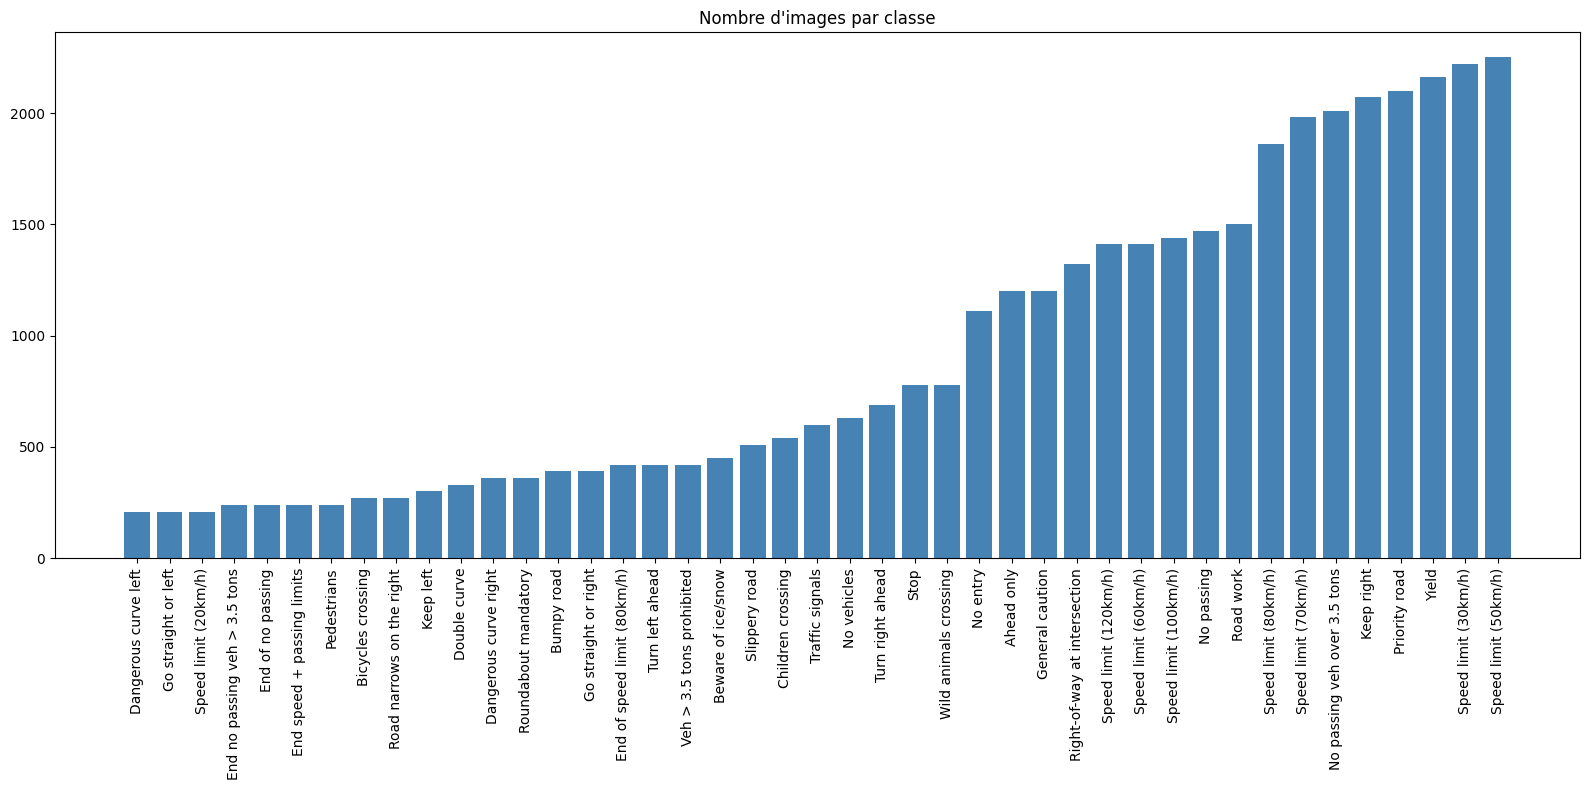

In [8]:
folders = os.listdir(TRAIN_DIR)
train_num = []
class_num = []

for folder in folders:
    train_files = os.listdir(os.path.join(TRAIN_DIR, folder))
    train_num.append(len(train_files))
    class_num.append(classes[int(folder)])

zipped_lists = zip(train_num, class_num)
sorted_pairs = sorted(zipped_lists)
tuples = zip(*sorted_pairs)
train_num, class_num = [list(t) for t in tuples]

plt.figure(figsize=(16, 8))
plt.bar(class_num, train_num, color='steelblue')
plt.xticks(class_num, rotation='vertical')
plt.title('Nombre d\'images par classe')
plt.tight_layout()
plt.show()

# CELLULE 5 — Visualiser des images aléatoires du test set

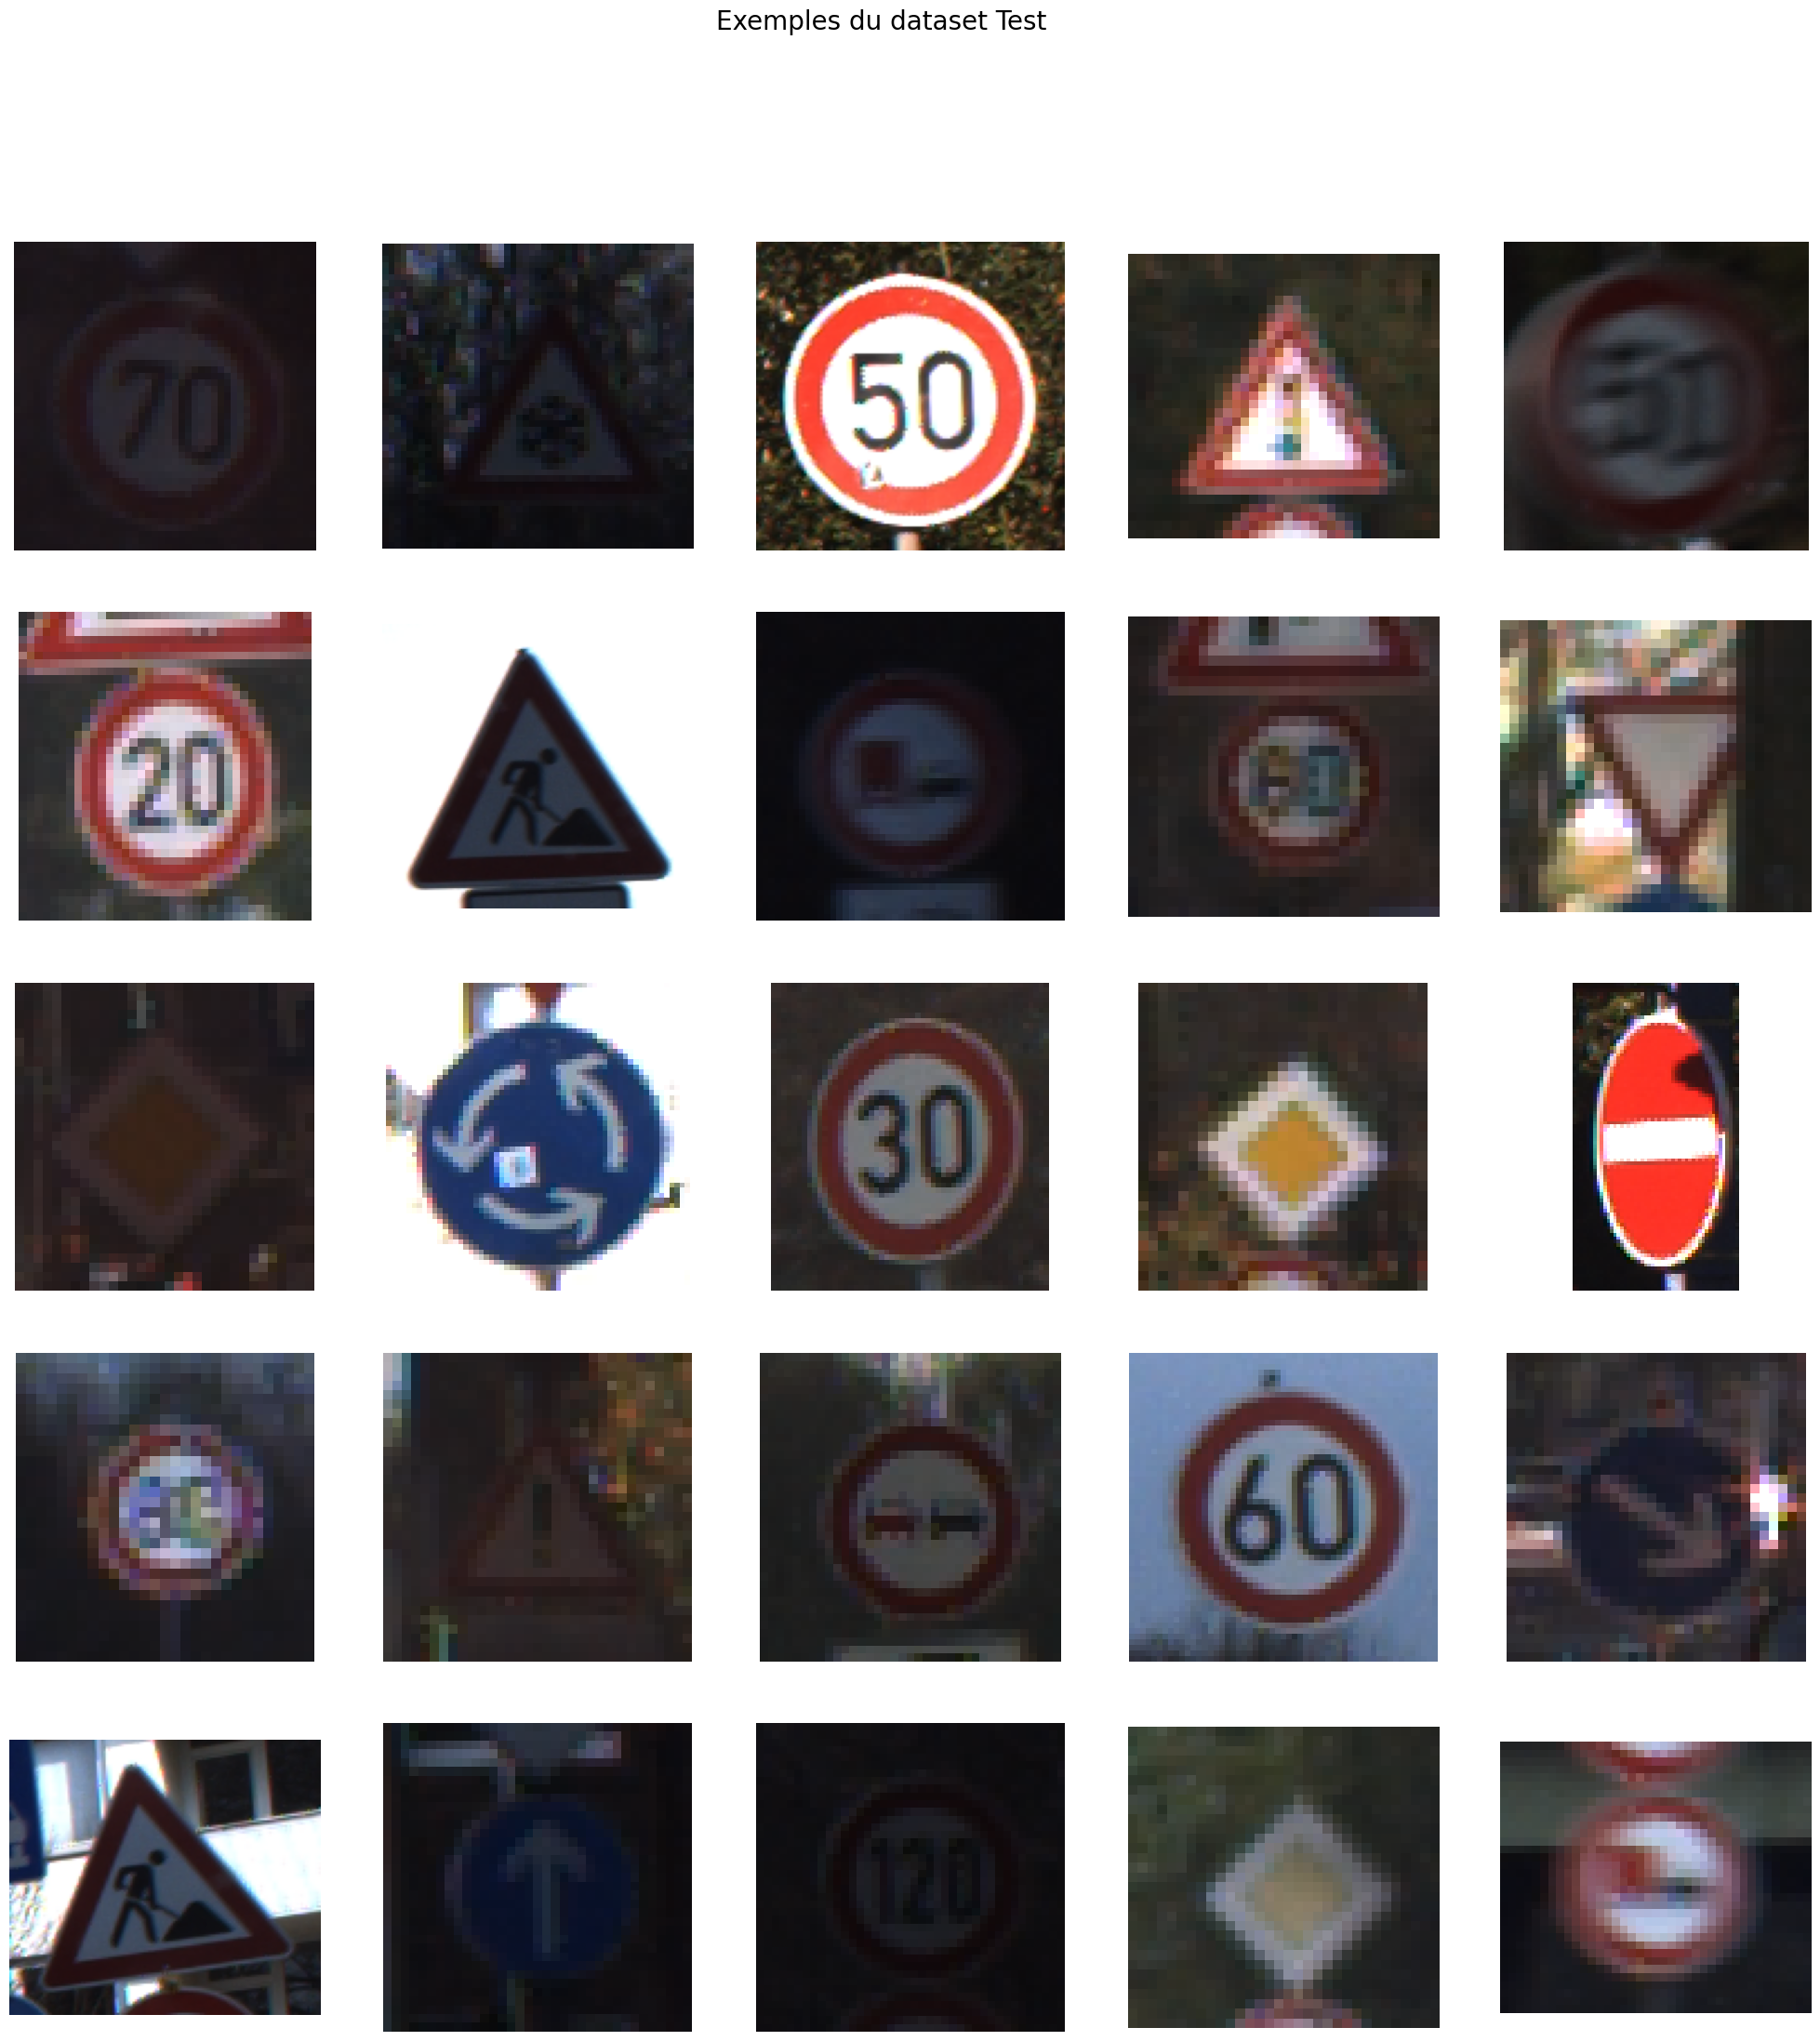

In [9]:
test_csv = pd.read_csv(os.path.join(DATA_DIR, 'Test.csv'))
imgs = test_csv['Path'].values

plt.figure(figsize=(25, 25))
for i in range(25):
    plt.subplot(5, 5, i+1)
    random_img_path = os.path.join(DATA_DIR, random.choice(imgs))
    rand_img = imread(random_img_path)
    plt.imshow(rand_img)
    plt.axis('off')
plt.suptitle('Exemples du dataset Test', fontsize=20)
plt.show()

# CELLULE 6 — Charger les données d'entraînement

In [10]:
start        = time.time()
image_data   = []
image_labels = []

for i in range(NUM_CLASSES):
    path   = os.path.join(TRAIN_DIR, str(i))
    images = os.listdir(path)
    for img in images:
        try:
            image         = cv2.imread(os.path.join(path, img))
            image_rgb     = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            image_pil     = Image.fromarray(image_rgb)
            resized_image = image_pil.resize((IMG_HEIGHT, IMG_WIDTH))
            image_data.append(np.array(resized_image))
            image_labels.append(i)
        except Exception as e:
            print(f'Erreur sur {img}: {e}')

image_data   = np.array(image_data)
image_labels = np.array(image_labels)

print(f'✅ Données chargées en {(time.time()-start)/60:.1f} minutes')
print(f'   Images : {image_data.shape}')
print(f'   Labels : {image_labels.shape}')

✅ Données chargées en 4.8 minutes
   Images : (39209, 30, 30, 3)
   Labels : (39209,)


# CELLULE 7 — Split train / validation + normalisation

In [11]:
shuffled_indices = np.arange(image_data.shape[0])
np.random.shuffle(shuffled_indices)
image_data   = image_data[shuffled_indices]
image_labels = image_labels[shuffled_indices]

X_train, X_valid, y_train, y_valid = train_test_split(
    image_data, image_labels, test_size=0.3, random_state=42, shuffle=True
)

X_train = X_train / 255.
X_valid = X_valid / 255.

y_train = to_categorical(y_train, NUM_CLASSES)
y_valid = to_categorical(y_valid, NUM_CLASSES)

print('✅ Données préparées')
print(f'   X_train : {X_train.shape}  |  y_train : {y_train.shape}')
print(f'   X_valid : {X_valid.shape}  |  y_valid : {y_valid.shape}')

✅ Données préparées
   X_train : (27446, 30, 30, 3)  |  y_train : (27446, 43)
   X_valid : (11763, 30, 30, 3)  |  y_valid : (11763, 43)


# CELLULE 8 — Construire le modèle CNN

In [12]:
model = keras.models.Sequential([
    Input((IMG_HEIGHT, IMG_WIDTH, CHANNELS)),

    Conv2D(16, (5, 5)),
    Conv2D(32, (5, 5)),
    BatchNormalization(axis=-1),
    Activation('relu'),
    MaxPool2D((2, 2)),
    Dropout(0.25),

    Conv2D(64, (3, 3)),
    Conv2D(128, (3, 3)),
    BatchNormalization(axis=-1),
    Activation('relu'),
    MaxPool2D((2, 2)),
    Dropout(0.25),

    GlobalAveragePooling2D(),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),

    Dense(NUM_CLASSES, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 16)     │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 22, 22, 32)     │        12,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 22, 22, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 22, 22, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 11, 11, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 11, 11, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 9, 9, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │        22,059 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 197,195 (770.29 KB)

 Trainable params: 195,851 (765.04 KB)

 Non-trainable params: 1,344 (5.25 KB)

# CELLULE 9 — Compiler le modèle

In [13]:
lr     = 0.001
epochs = 20

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=lr),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.08),
    metrics=['accuracy']
)

print(f'✅ Modèle compilé — lr={lr}, epochs={epochs}')

✅ Modèle compilé — lr=0.001, epochs=20


# CELLULE 10 — Data augmentation

In [14]:
augmentor = ImageDataGenerator(
    rotation_range=15,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.15,
    horizontal_flip=False,
    vertical_flip=False,
    fill_mode='nearest'
)

print('✅ Data augmentation configurée')

✅ Data augmentation configurée


# CELLULE 11 — Entraîner le modèle

In [15]:
start = time.time()

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath='best_model.keras',
        monitor='val_accuracy',
        mode='max',
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        verbose=1
    )
]

history = model.fit(
    augmentor.flow(X_train, y_train, batch_size=32),
    epochs=epochs,
    validation_data=(X_valid, y_valid),
    callbacks=callbacks
)

print(f'\n✅ Entraînement terminé en {(time.time()-start)/60:.1f} minutes')

Epoch 1/20
858/858 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.2153 - loss: 3.3282
Epoch 1: val_accuracy improved from None to 0.73408, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
858/858 ━━━━━━━━━━━━━━━━━━━━ 30s 25ms/step - accuracy: 0.3602 - loss: 2.6389 - val_accuracy: 0.7341 - val_loss: 1.4443 - learning_rate: 0.0010
Epoch 2/20
855/858 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6345 - loss: 1.7027
Epoch 2: val_accuracy improved from 0.73408 to 0.84851, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
858/858 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - accuracy: 0.6798 - loss: 1.5847 - val_accuracy: 0.8485 - val_loss: 1.1880 - learning_rate: 0.0010
Epoch 3/20
858/858 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7597 - loss: 1.3805
Epoch 3: val_accuracy improved from 0.84851 to 0.93590, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
858/858 ━━━━━━━━━━━━━━━━━━━━ 15s 

# CELLULE 12 — Visualiser les courbes d'entraînement

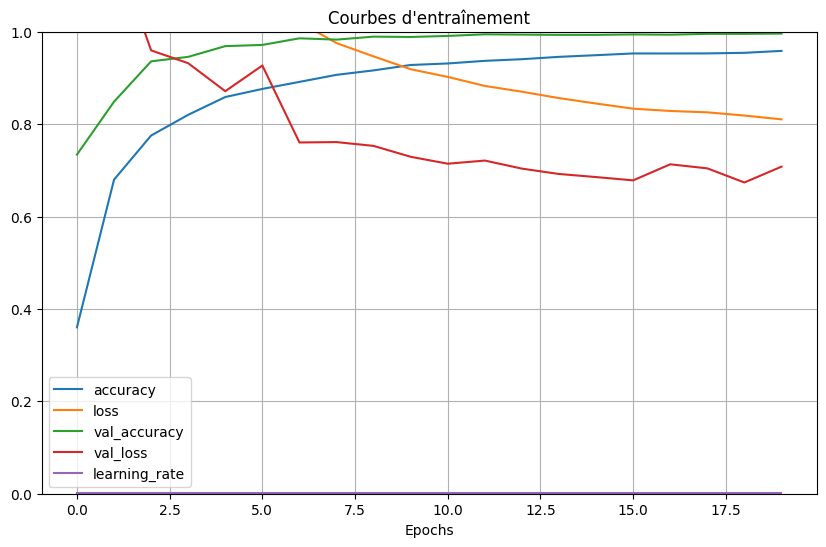

In [16]:
pd.DataFrame(history.history).plot(figsize=(10, 6))
plt.grid(True)
plt.gca().set_ylim(0, 1)
plt.title('Courbes d\'entraînement')
plt.xlabel('Epochs')
plt.show()

# CELLULE 13 — Charger les données de test et évaluer

In [17]:
test_csv = pd.read_csv(os.path.join(DATA_DIR, 'Test.csv'))
labels   = test_csv['ClassId'].values
imgs     = test_csv['Path'].values

data = []
for img in imgs:
    try:
        image     = cv2.imread(os.path.join(DATA_DIR, img))
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image_pil = Image.fromarray(image_rgb)
        resized   = image_pil.resize((IMG_HEIGHT, IMG_WIDTH))
        data.append(np.array(resized))
    except Exception as e:
        print(f'Erreur : {e}')

X_test = np.array(data) / 255.
y_test = to_categorical(labels, NUM_CLASSES)

loss_val, acc_val = model.evaluate(X_test, y_test, verbose=0)
print(f'✅ Évaluation terminée')
print(f'   Loss     : {loss_val:.4f}')
print(f'   Accuracy : {acc_val*100:.2f}%')

✅ Évaluation terminée
   Loss     : 0.7479
   Accuracy : 96.68%


# CELLULE 14 — Matrice de confusion

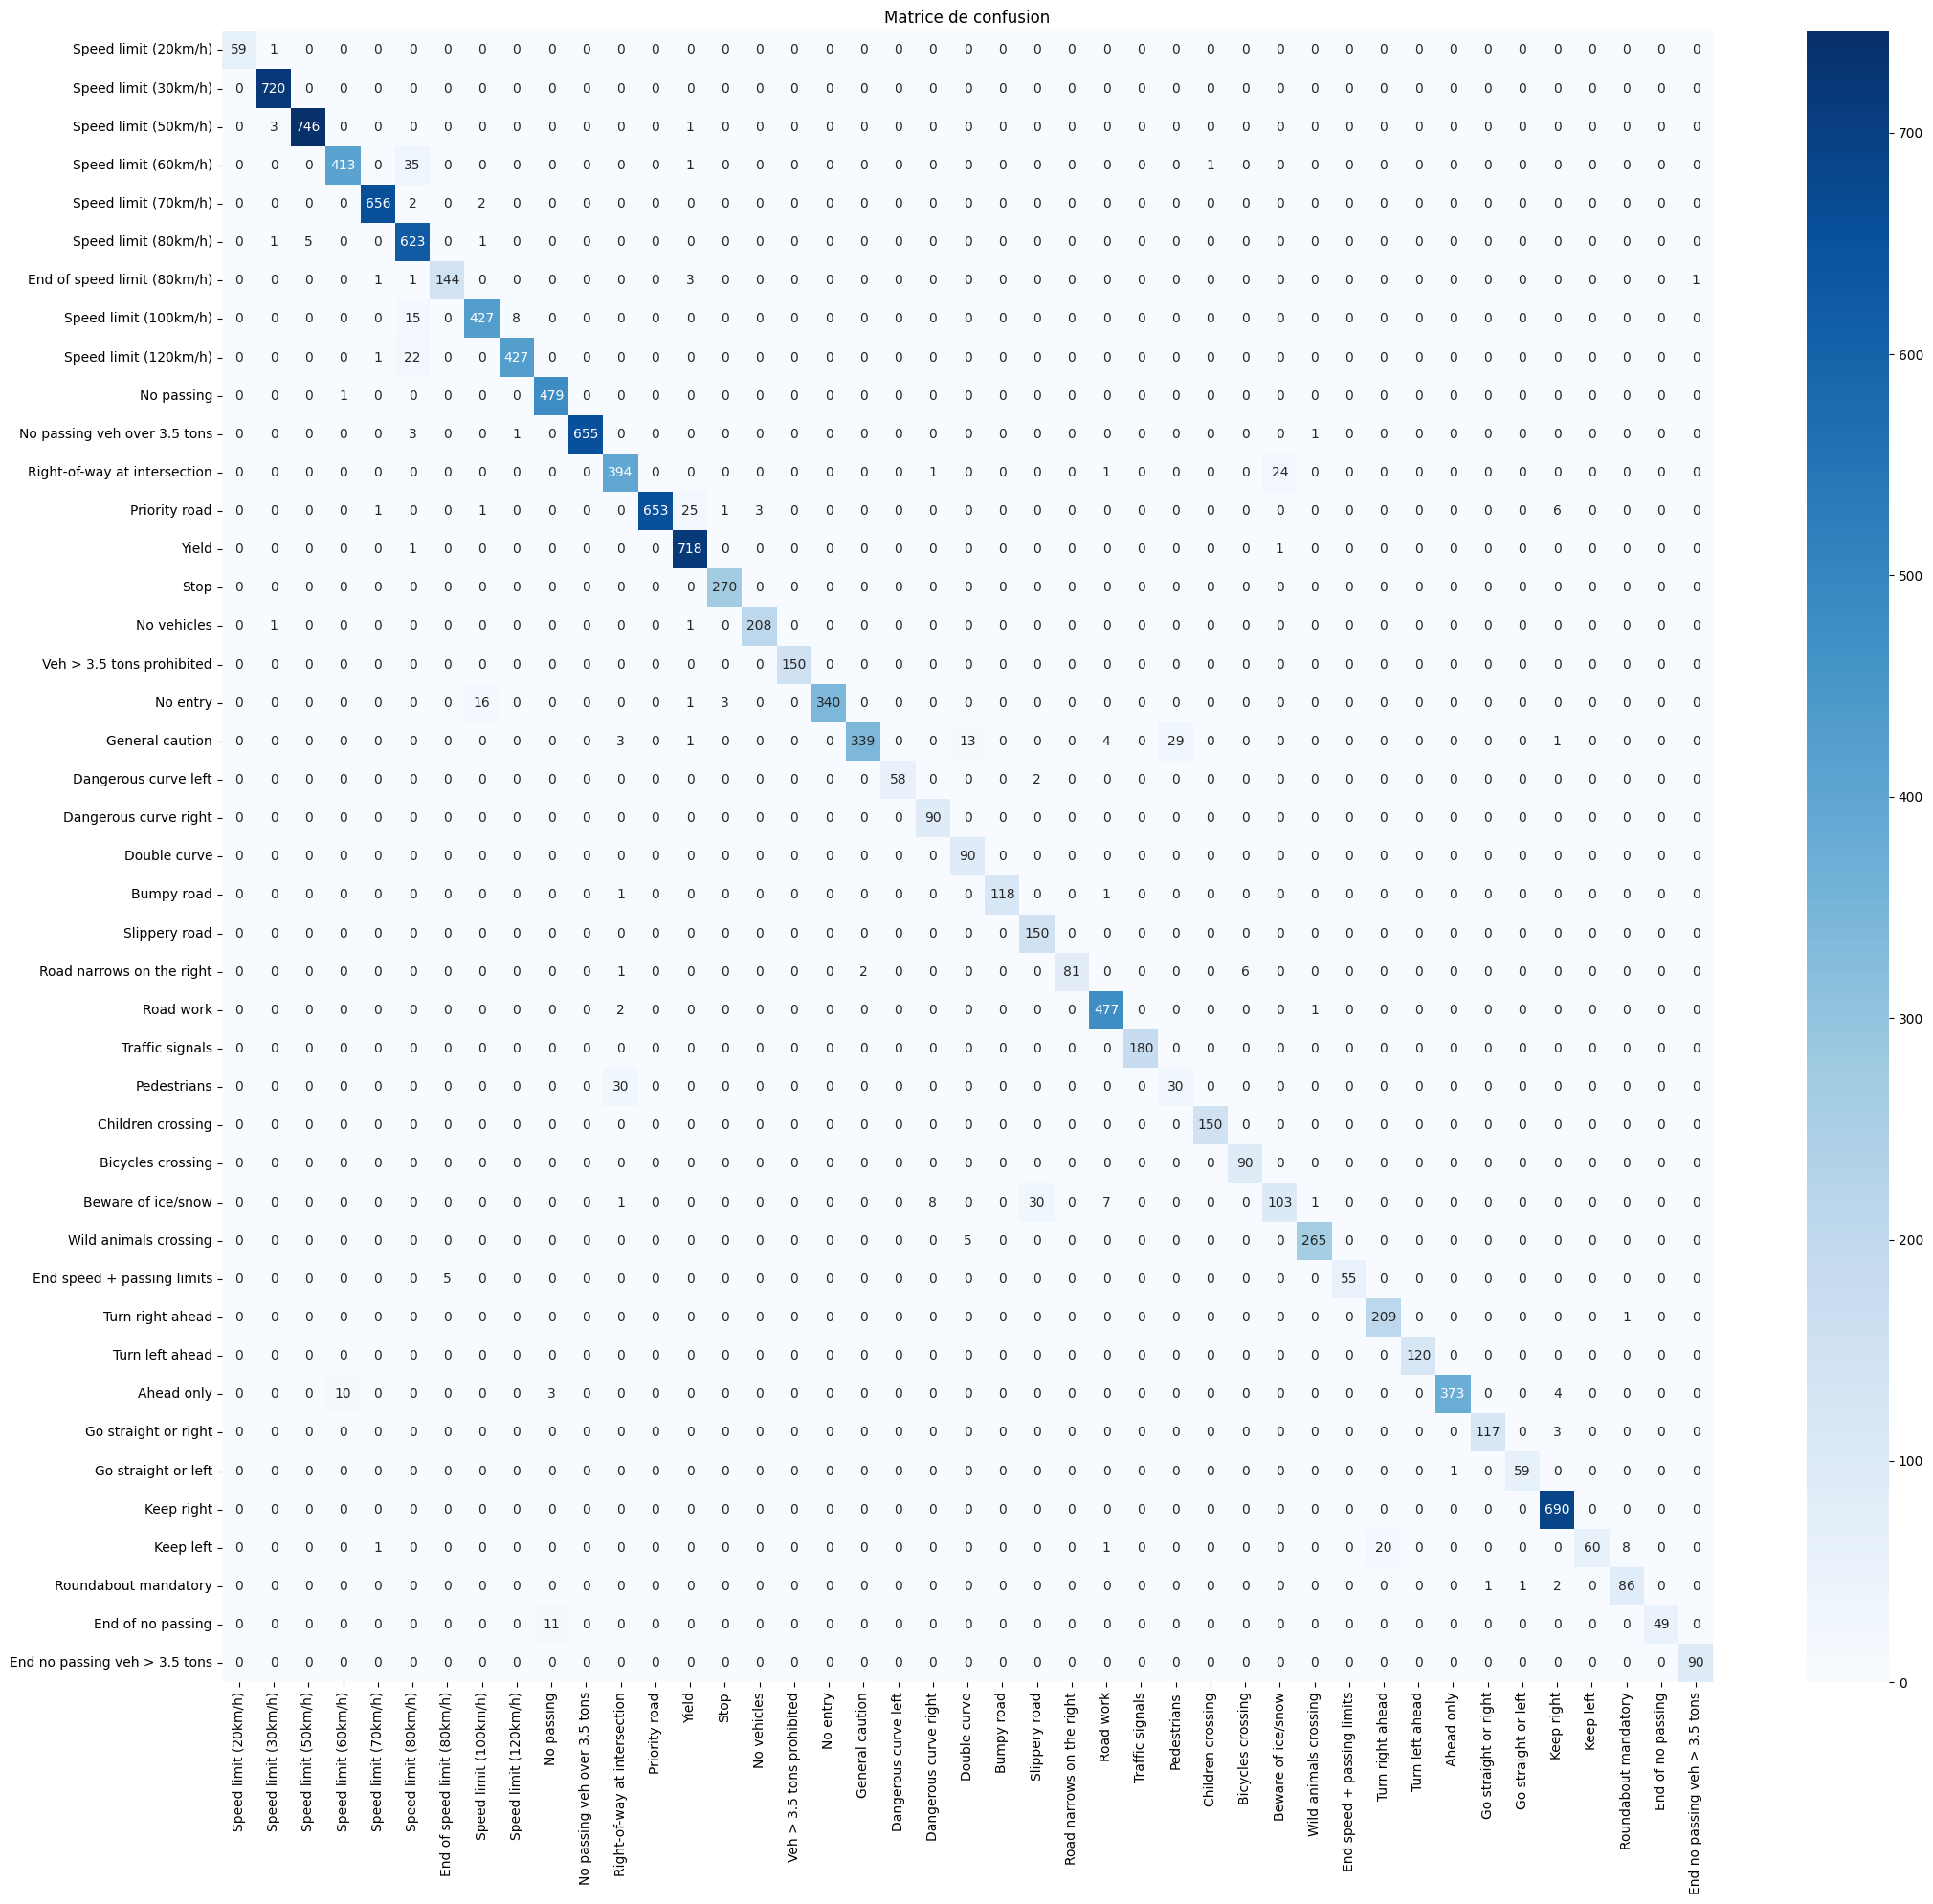

In [18]:
preds = model.predict(X_test, verbose=0)
cf    = confusion_matrix(labels, np.argmax(preds, axis=1))

df_cm = pd.DataFrame(cf, index=classes.values(), columns=classes.values())
plt.figure(figsize=(22, 20))
sns.heatmap(df_cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matrice de confusion')
plt.tight_layout()
plt.show()

# CELLULE 15 — Rapport de classification

In [19]:
print(classification_report(
    labels,
    np.argmax(preds, axis=1),
    target_names=list(classes.values())
))

                               precision    recall  f1-score   support

         Speed limit (20km/h)       1.00      0.98      0.99        60
         Speed limit (30km/h)       0.99      1.00      1.00       720
         Speed limit (50km/h)       0.99      0.99      0.99       750
         Speed limit (60km/h)       0.97      0.92      0.95       450
         Speed limit (70km/h)       0.99      0.99      0.99       660
         Speed limit (80km/h)       0.89      0.99      0.94       630
  End of speed limit (80km/h)       0.97      0.96      0.96       150
        Speed limit (100km/h)       0.96      0.95      0.95       450
        Speed limit (120km/h)       0.98      0.95      0.96       450
                   No passing       0.97      1.00      0.98       480
 No passing veh over 3.5 tons       1.00      0.99      1.00       660
 Right-of-way at intersection       0.91      0.94      0.92       420
                Priority road       1.00      0.95      0.97       690
     

# CELLULE 16 — Precision et Recall par classe (graphique)

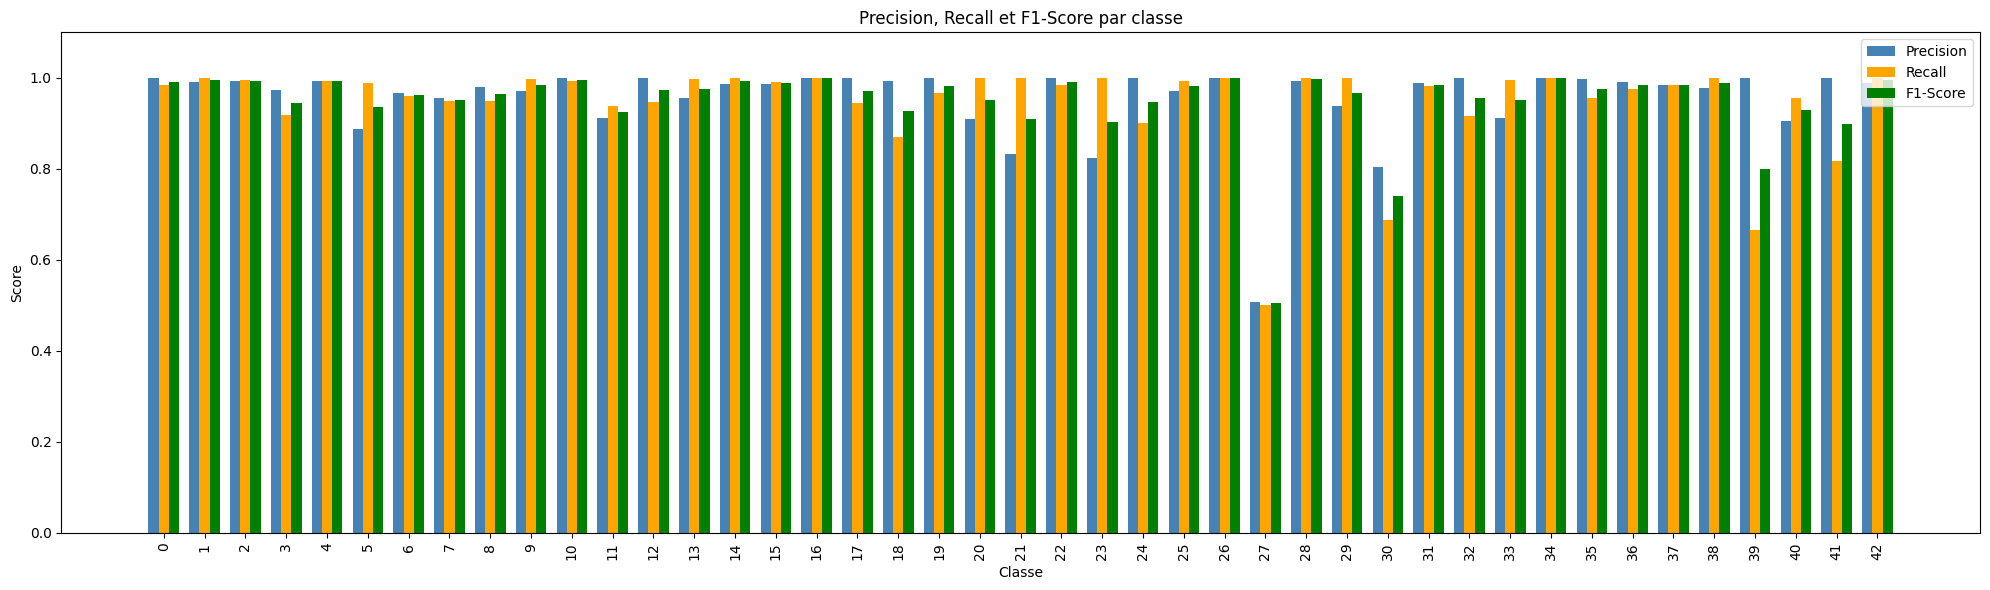


✅ Moyennes globales :
   Precision : 0.9552
   Recall    : 0.9463
   F1-Score  : 0.9488


In [20]:
from sklearn.metrics import precision_score, recall_score, f1_score

y_pred = np.argmax(preds, axis=1)

precision = precision_score(labels, y_pred, average=None, zero_division=0)
recall    = recall_score(labels, y_pred, average=None, zero_division=0)
f1        = f1_score(labels, y_pred, average=None, zero_division=0)

x = np.arange(NUM_CLASSES)
width = 0.25

fig, ax = plt.subplots(figsize=(20, 6))
ax.bar(x - width, precision, width, label='Precision', color='steelblue')
ax.bar(x,         recall,    width, label='Recall',    color='orange')
ax.bar(x + width, f1,        width, label='F1-Score',  color='green')

ax.set_xlabel('Classe')
ax.set_ylabel('Score')
ax.set_title('Precision, Recall et F1-Score par classe')
ax.set_xticks(x)
ax.set_xticklabels([str(i) for i in range(NUM_CLASSES)], rotation=90)
ax.legend()
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.show()

print(f'\n✅ Moyennes globales :')
print(f'   Precision : {precision.mean():.4f}')
print(f'   Recall    : {recall.mean():.4f}')
print(f'   F1-Score  : {f1.mean():.4f}')

# CELLULE 17 —  Images mal classifiées

❌ Nombre d'erreurs : 419 / 12630
   Accuracy : 96.68%


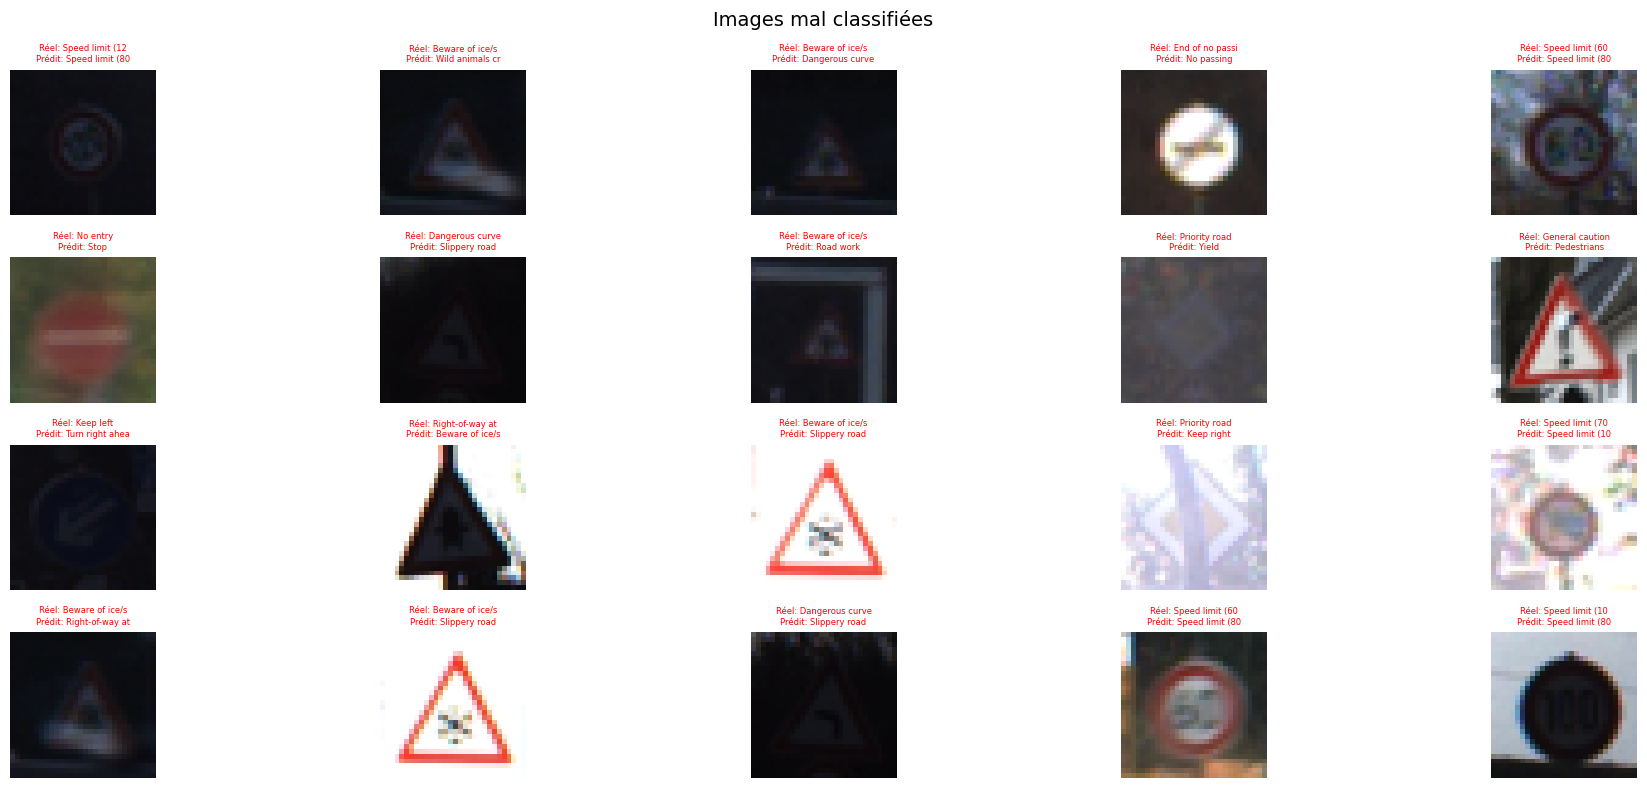

In [21]:
y_pred       = np.argmax(preds, axis=1)
wrong_indices = np.where(y_pred != labels)[0]

print(f'❌ Nombre d\'erreurs : {len(wrong_indices)} / {len(labels)}')
print(f'   Accuracy : {(1 - len(wrong_indices)/len(labels))*100:.2f}%')

plt.figure(figsize=(20, 8))
shown = 0
for idx in wrong_indices:
    if shown >= 20:
        break
    plt.subplot(4, 5, shown + 1)
    plt.imshow(X_test[idx])
    plt.axis('off')
    plt.title(
        f'Réel: {classes[labels[idx]][:15]}\nPrédit: {classes[y_pred[idx]][:15]}',
        fontsize=6, color='red'
    )
    shown += 1

plt.suptitle('Images mal classifiées', fontsize=14)
plt.tight_layout()
plt.show()

# CELLULE 18 — Top-5 prédictions

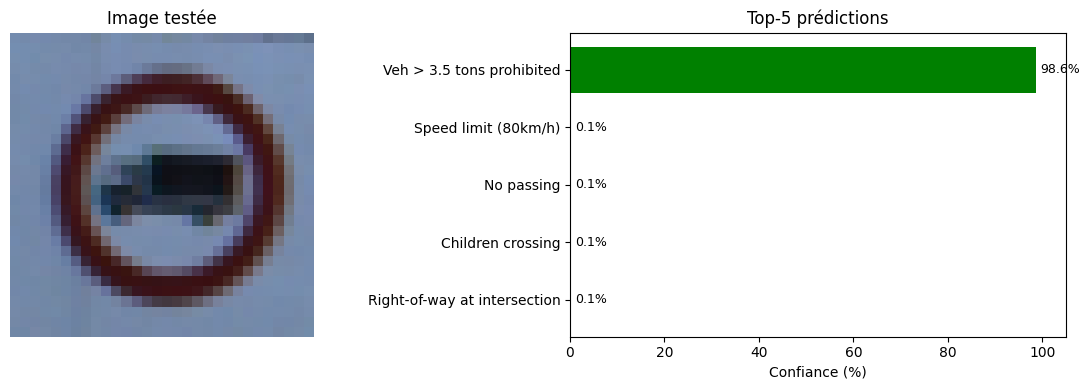

✅ Prédiction : Veh > 3.5 tons prohibited (98.63%)


In [22]:
def predict_top5(image_path):
    image     = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image_pil = Image.fromarray(image_rgb)
    resized   = image_pil.resize((IMG_HEIGHT, IMG_WIDTH))

    img_array  = np.array(resized) / 255.
    img_array  = np.expand_dims(img_array, axis=0)
    prediction = model.predict(img_array, verbose=0)[0]

    top5_idx   = np.argsort(prediction)[::-1][:5]
    top5_conf  = prediction[top5_idx] * 100

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.imshow(resized)
    ax1.axis('off')
    ax1.set_title('Image testée', fontsize=12)

    colors = ['green' if i == 0 else 'steelblue' for i in range(5)]
    bars   = ax2.barh(
        [classes[i][:30] for i in top5_idx][::-1],
        top5_conf[::-1],
        color=colors[::-1]
    )
    ax2.set_xlabel('Confiance (%)')
    ax2.set_title('Top-5 prédictions')
    ax2.set_xlim(0, 105)

    for bar, conf in zip(bars, top5_conf[::-1]):
        ax2.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                 f'{conf:.1f}%', va='center', fontsize=9)

    plt.tight_layout()
    plt.show()
    print(f'✅ Prédiction : {classes[top5_idx[0]]} ({top5_conf[0]:.2f}%)')

# Exemple
predict_top5(os.path.join(DATA_DIR, 'Test/00000.png'))

# CELLULE 19 —  Grad-CAM

✅ Dernière couche Conv2D : conv2d_3


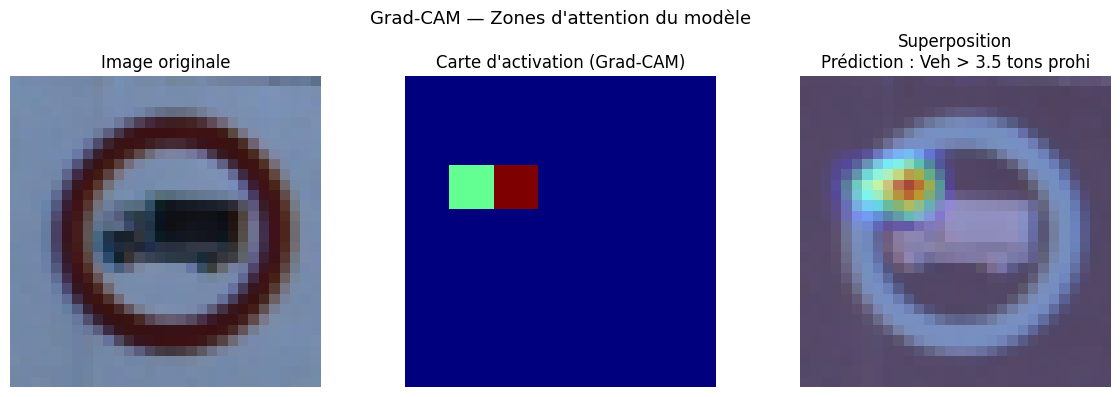

✅ Prédiction : Veh > 3.5 tons prohibited


In [23]:
import tensorflow as tf

# Trouver la dernière couche Conv2D
last_conv_layer_name = None
for layer in model.layers:
    if 'conv2d' in layer.name:
        last_conv_layer_name = layer.name
print(f'✅ Dernière couche Conv2D : {last_conv_layer_name}')

def make_gradcam(img_array, model, last_conv_layer_name):
    # Construire le modèle fonctionnel depuis les layers
    inputs = model.layers[0].input if hasattr(model.layers[0], 'input') else tf.keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, CHANNELS))
    
    # Reconstruire avec API fonctionnelle
    x = inputs
    conv_output = None
    for layer in model.layers:
        x = layer(x)
        if layer.name == last_conv_layer_name:
            conv_output = x

    grad_model = tf.keras.Model(inputs=inputs, outputs=[conv_output, x])

    img_tensor = tf.cast(img_array, tf.float32)
    with tf.GradientTape() as tape:
        tape.watch(img_tensor)
        conv_out, predictions = grad_model(img_tensor)
        predicted_class = tf.argmax(predictions[0])
        loss = predictions[:, predicted_class]

    grads        = tape.gradient(loss, conv_out)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap      = conv_out[0] @ pooled_grads[..., tf.newaxis]
    heatmap      = tf.squeeze(heatmap)
    heatmap      = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), int(predicted_class.numpy())

def show_gradcam(image_path):
    image     = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image_pil = Image.fromarray(image_rgb)
    resized   = image_pil.resize((IMG_HEIGHT, IMG_WIDTH))
    img_array = np.array(resized) / 255.
    img_array = np.expand_dims(img_array, axis=0).astype(np.float32)

    heatmap, pred_class = make_gradcam(img_array, model, last_conv_layer_name)

    heatmap_resized = cv2.resize(heatmap, (IMG_WIDTH, IMG_HEIGHT))
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    heatmap_rgb     = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
    img_uint8       = np.uint8(255 * np.array(resized))
    superimposed    = cv2.addWeighted(img_uint8, 0.6, heatmap_rgb, 0.4, 0)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(resized)
    axes[0].set_title('Image originale')
    axes[0].axis('off')

    axes[1].imshow(heatmap, cmap='jet')
    axes[1].set_title('Carte d\'activation (Grad-CAM)')
    axes[1].axis('off')

    axes[2].imshow(superimposed)
    axes[2].set_title(f'Superposition\nPrédiction : {classes[pred_class][:20]}')
    axes[2].axis('off')

    plt.suptitle('Grad-CAM — Zones d\'attention du modèle', fontsize=13)
    plt.tight_layout()
    plt.show()
    print(f'✅ Prédiction : {classes[pred_class]}')

# Exemple
show_gradcam(os.path.join(DATA_DIR, 'Test/00000.png'))

# CELLULE 20 — Charger le modèle sauvegardé (sans réentraîner)

In [24]:
model = keras.models.load_model('best_model.keras')
print('✅ Modèle chargé depuis best_model.keras')

✅ Modèle chargé depuis best_model.keras


# CELLULE 21 — Architecture du modéle CNN

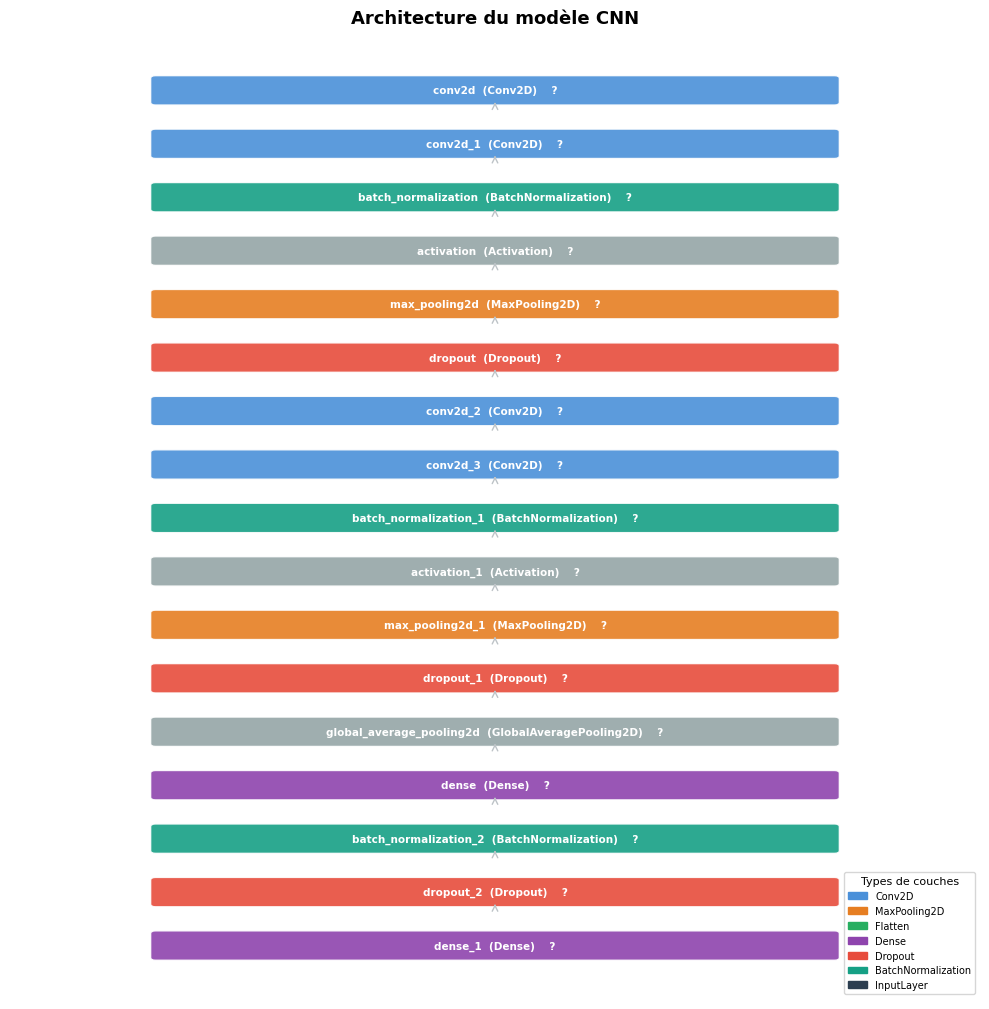

✅ Image sauvegardée : architecture_cnn.png


In [25]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

def plot_cnn_architecture(model):
    layer_colors = {
        'Conv2D': '#4A90D9',
        'MaxPooling2D': '#E67E22',
        'Flatten': '#27AE60',
        'Dense': '#8E44AD',
        'Dropout': '#E74C3C',
        'BatchNormalization': '#16A085',
        'InputLayer': '#2C3E50',
    }
    default_color = '#95A5A6'

    layers = model.layers
    n = len(layers)
    fig_height = max(4, n * 0.6)
    fig, ax = plt.subplots(figsize=(10, fig_height))
    ax.set_xlim(0, 10)
    ax.set_ylim(0, n + 1)
    ax.axis('off')

    box_width, box_height = 7, 0.45
    x_start = 1.5

    for i, layer in enumerate(layers):
        y = n - i
        layer_type = type(layer).__name__
        color = layer_colors.get(layer_type, default_color)

        # Boîte de la couche
        rect = mpatches.FancyBboxPatch(
            (x_start, y - box_height / 2), box_width, box_height,
            boxstyle="round,pad=0.05",
            linewidth=1, edgecolor='white',
            facecolor=color, alpha=0.9
        )
        ax.add_patch(rect)

        # Nom + forme de sortie
        try:
            shape = str(layer.output_shape)
        except:
            shape = "?"
        label = f"{layer.name}  ({layer_type})    {shape}"
        ax.text(x_start + box_width / 2, y, label,
                ha='center', va='center',
                fontsize=7.5, color='white', fontweight='bold')

        # Flèche entre couches
        if i < n - 1:
            ax.annotate('', xy=(5, y - box_height / 2),
                        xytext=(5, y - box_height / 2 - 0.08),
                        arrowprops=dict(arrowstyle='->', color='#BDC3C7', lw=1))

    # Légende
    legend_patches = [
        mpatches.Patch(color=c, label=t) for t, c in layer_colors.items()
    ]
    ax.legend(handles=legend_patches, loc='lower right',
              fontsize=7, framealpha=0.8, title="Types de couches", title_fontsize=8)

    plt.title("Architecture du modèle CNN", fontsize=13, fontweight='bold', pad=10)
    plt.tight_layout()
    plt.savefig('architecture_cnn.png', dpi=120, bbox_inches='tight',
                facecolor='#1E1E2E')
    plt.show()
    print("✅ Image sauvegardée : architecture_cnn.png")

plot_cnn_architecture(model)

# CELLULE 22 — Tester avec vos propres images

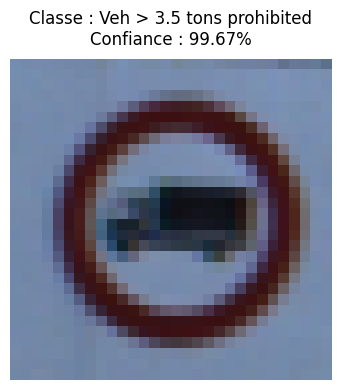

✅ Prédiction : Veh > 3.5 tons prohibited (99.67%)


In [26]:
def predict_image(image_path):
    """
    Prédit la classe d'un panneau de signalisation.
    Args:
        image_path (str): Chemin vers l'image à tester
    """
    image     = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image_pil = Image.fromarray(image_rgb)
    resized   = image_pil.resize((IMG_HEIGHT, IMG_WIDTH))

    img_array = np.array(resized) / 255.
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array, verbose=0)
    class_id   = np.argmax(prediction)
    confidence = np.max(prediction) * 100

    plt.figure(figsize=(4, 4))
    plt.imshow(resized)
    plt.axis('off')
    plt.title(
        f'Classe : {classes[class_id]}\nConfiance : {confidence:.2f}%',
        fontsize=12, pad=10
    )
    plt.tight_layout()
    plt.show()

    print(f'✅ Prédiction : {classes[class_id]} ({confidence:.2f}%)')


# ---- Exemple d'utilisation ----

predict_image(os.path.join(DATA_DIR, 'Test/00000.png'))

# CELLULE 23 — Tester plusieurs images à la fois

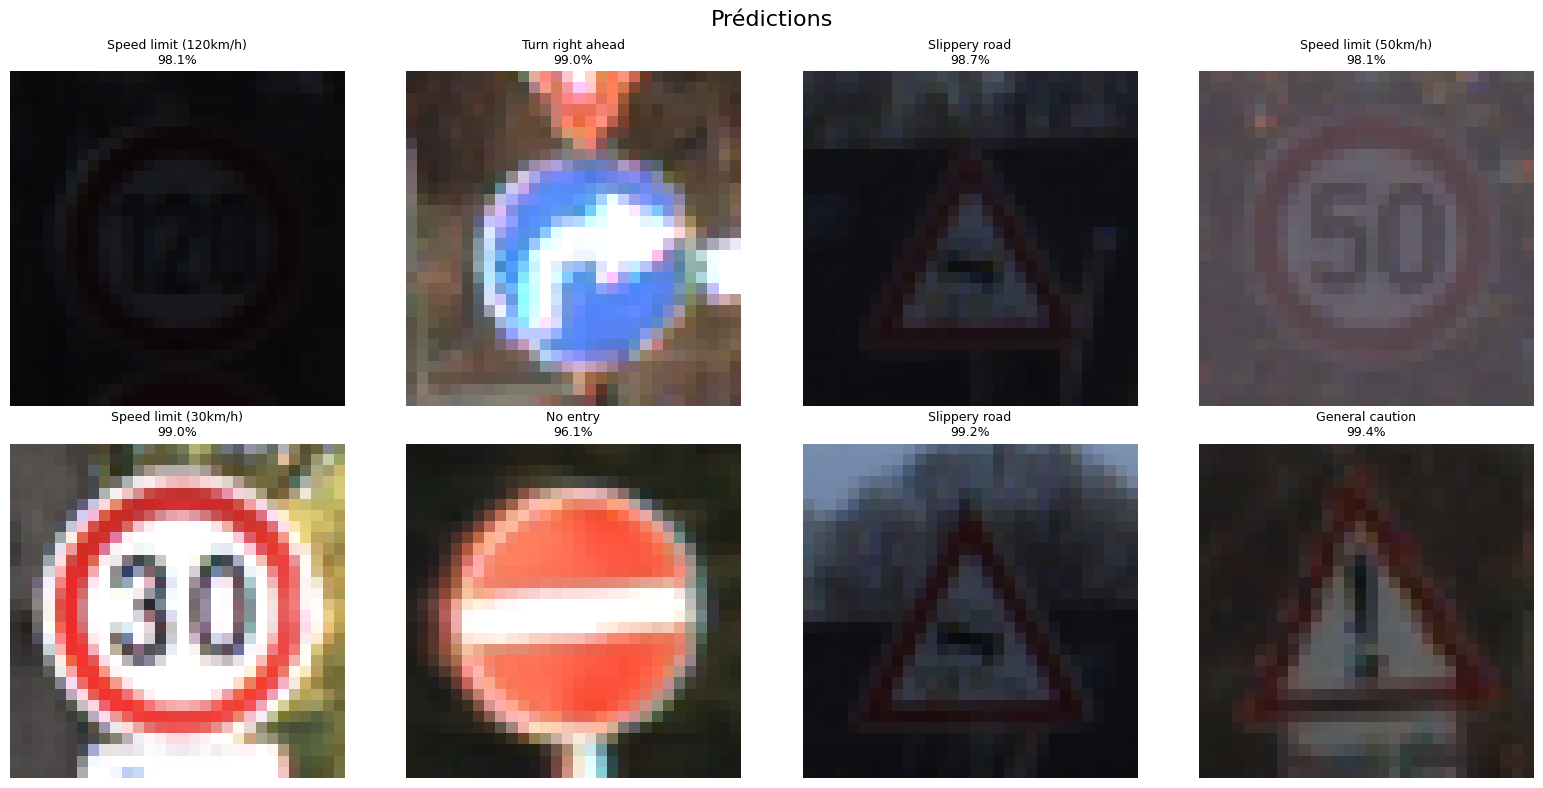

In [27]:
def predict_multiple(image_paths, cols=4):
    """
    Affiche une grille de prédictions.
    Args:
        image_paths (list): Liste de chemins d'images
        cols (int): Nombre de colonnes dans la grille
    """
    rows = (len(image_paths) + cols - 1) // cols
    plt.figure(figsize=(cols * 4, rows * 4))

    for idx, image_path in enumerate(image_paths):
        image     = cv2.imread(image_path)
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image_pil = Image.fromarray(image_rgb)
        resized   = image_pil.resize((IMG_HEIGHT, IMG_WIDTH))

        img_array  = np.array(resized) / 255.
        img_array  = np.expand_dims(img_array, axis=0)
        prediction = model.predict(img_array, verbose=0)
        class_id   = np.argmax(prediction)
        confidence = np.max(prediction) * 100

        plt.subplot(rows, cols, idx + 1)
        plt.imshow(resized)
        plt.axis('off')
        plt.title(f'{classes[class_id]}\n{confidence:.1f}%', fontsize=9)

    plt.suptitle('Prédictions', fontsize=16)
    plt.tight_layout()
    plt.show()


# ---- Exemple avec 8 images aléatoires du test set ----
sample_paths = [
    os.path.join(DATA_DIR, p)
    for p in random.sample(list(test_csv['Path'].values), 8)
]
predict_multiple(sample_paths)

# CELLULE 24 — Tester vos images 

In [28]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import io

output = widgets.Output()

def predict_image(image_bytes):
    image    = Image.open(io.BytesIO(image_bytes)).convert('RGB')
    resized  = image.resize((IMG_HEIGHT, IMG_WIDTH))

    img_array  = np.array(resized) / 255.
    img_array  = np.expand_dims(img_array, axis=0)
    prediction = model.predict(img_array, verbose=0)
    class_id   = np.argmax(prediction)
    confidence = np.max(prediction) * 100

    with output:
        clear_output(wait=True)
        plt.figure(figsize=(4, 4))
        plt.imshow(image)
        plt.axis('off')
        plt.title(f'{classes[class_id]}\nConfiance : {confidence:.2f}%', fontsize=12)
        plt.tight_layout()
        plt.show()
        print(f'✅ Prédiction : {classes[class_id]}')
        print(f'   Confiance  : {confidence:.2f}%')

uploader = widgets.FileUpload(accept='image/*', multiple=False)

def on_upload(change):
    if uploader.value:
        # Compatible nouvelle version ipywidgets
        files = uploader.value
        if isinstance(files, dict):
            image_bytes = list(files.values())[0]['content']
        else:
            image_bytes = files[0]['content']
        predict_image(bytes(image_bytes))

uploader.observe(on_upload, names='value')

btn = widgets.Button(description='Prédire', button_style='success')

def on_click(b):
    if uploader.value:
        files = uploader.value
        if isinstance(files, dict):
            image_bytes = list(files.values())[0]['content']
        else:
            image_bytes = files[0]['content']
        predict_image(bytes(image_bytes))

btn.on_click(on_click)

print('📁 1. Uploadez une image   2. Cliquez sur Prédire')
display(uploader, btn, output)

📁 1. Uploadez une image   2. Cliquez sur Prédire


FileUpload(value=(), accept='image/*', description='Upload')

Button(button_style='success', description='Prédire', style=ButtonStyle())

Output()